# Evaluación del filtrado colaborativo basado en usuarios

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Carga del conjunto de datos

In [2]:
DATA_DIR = Path("../data/raw/ml-latest-small")

ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")

## División en entrenamiento y prueba

In [3]:
train_parts = []
test_parts = []

for user_id, valoraciones_usuario in ratings.groupby("userId"):

    train_user, test_user = train_test_split(
        valoraciones_usuario,
        test_size=0.2,
        random_state=42
    )

    train_parts.append(train_user)
    test_parts.append(test_user)

ratings_train = pd.concat(train_parts)
ratings_test = pd.concat(test_parts)

In [4]:
print("Valoraciones entrenamiento:", len(ratings_train))
print("Valoraciones prueba:", len(ratings_test))

Valoraciones entrenamiento: 80419
Valoraciones prueba: 20417


## Construcción del modelo a partir del conjunto de entrenamiento

In [5]:
matriz_train = ratings_train.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

matriz_train.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
media_train_por_usuario = matriz_train.mean(axis=1)

matriz_train_normalizada = matriz_train.sub(
    media_train_por_usuario,
    axis=0
)

matriz_train_normalizada.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.372973,NaN,-0.372973,NaN,NaN,-0.372973,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.342857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
matriz_train_similitud = matriz_train_normalizada.fillna(0)

similitud_train = cosine_similarity(
    matriz_train_similitud
)

similitud_train = pd.DataFrame(
    similitud_train,
    index=matriz_train.index,
    columns=matriz_train.index
)

similitud_train.iloc[:5, :5]

userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.000000,0.004246,0.007345,0.057831
2,0.000000,1.000000,0.000000,0.000000,0.022993
3,0.004246,0.000000,1.000000,0.000000,-0.035201
4,0.007345,0.000000,0.000000,1.000000,-0.035045
5,0.057831,0.022993,-0.035201,-0.035045,1.000000


## Función de predicción para el conjunto de prueba

In [8]:
def predecir_test(usuario_id, pelicula_id, k=10, min_vecinos=3):

    # Si la película no existe en entrenamiento, no podemos predecirla
    if pelicula_id not in matriz_train.columns:
        return np.nan

    # Similitudes del usuario con los demás
    similitudes_usuario = similitud_train.loc[usuario_id].drop(usuario_id)

    # Seleccionamos los k vecinos más similares
    vecinos = (
        similitudes_usuario
        .sort_values(ascending=False)
        .head(k)
    )

    # Desviaciones de esos vecinos para la película
    desviaciones = matriz_train_normalizada.loc[
        vecinos.index,
        pelicula_id
    ].dropna()

    # Exigimos un mínimo de evidencia
    if len(desviaciones) < min_vecinos:
        return np.nan

    # Nos quedamos con las similitudes de quienes sí la han valorado
    similitudes_validas = vecinos.loc[desviaciones.index]

    # Evitamos una división imposible
    if similitudes_validas.abs().sum() == 0:
        return np.nan

    desviacion_predicha = (
        desviaciones * similitudes_validas
    ).sum() / similitudes_validas.abs().sum()

    prediccion = (
        media_train_por_usuario.loc[usuario_id]
        + desviacion_predicha
    )

    # La escala real de MovieLens es 0.5–5
    prediccion = np.clip(prediccion, 0.5, 5.0)

    return prediccion

## Predicción de las valoraciones del conjunto de prueba

In [9]:
resultados = []

for fila in ratings_test.itertuples():

    prediccion = predecir_test(
        usuario_id=fila.userId,
        pelicula_id=fila.movieId,
        k=10,
        min_vecinos=3
    )

    if not np.isnan(prediccion):
        resultados.append({
            "userId": fila.userId,
            "movieId": fila.movieId,
            "real": fila.rating,
            "predicha": prediccion
        })

resultados = pd.DataFrame(resultados)

resultados.head()

,userId,movieId,real,predicha
0,1,3578,5.0,4.379052
1,1,1127,4.0,4.316769
2,1,260,5.0,5.000000
3,1,1732,5.0,3.660171
4,1,2054,4.0,4.071846


In [10]:
print("Valoraciones de test:", len(ratings_test))
print("Predicciones realizadas:", len(resultados))
print(
    "Cobertura:",
    f"{len(resultados) / len(ratings_test) * 100:.2f}%"
)

Valoraciones de test: 20417
Predicciones realizadas: 6313
Cobertura: 30.92%


## Métricas de evaluación

In [11]:
mae = mean_absolute_error(
    resultados["real"],
    resultados["predicha"]
)

rmse = np.sqrt(
    mean_squared_error(
        resultados["real"],
        resultados["predicha"]
    )
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE : 0.6399
RMSE: 0.8316


## Optimización del número de vecinos (k)

In [12]:
valores_k = [5, 10, 20, 30, 50]

metricas = []

In [13]:
for k in valores_k:

    resultados = []

    for fila in ratings_test.itertuples():

        prediccion = predecir_test(
            usuario_id=fila.userId,
            pelicula_id=fila.movieId,
            k=k,
            min_vecinos=3
        )

        if not np.isnan(prediccion):

            resultados.append({
                "real": fila.rating,
                "predicha": prediccion
            })

    resultados = pd.DataFrame(resultados)

    cobertura = len(resultados) / len(ratings_test) * 100

    mae = mean_absolute_error(
        resultados["real"],
        resultados["predicha"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            resultados["real"],
            resultados["predicha"]
        )
    )

    metricas.append({
        "k": k,
        "Cobertura": cobertura,
        "MAE": mae,
        "RMSE": rmse
    })

In [14]:
metricas = pd.DataFrame(metricas)

metricas

,k,Cobertura,MAE,RMSE
0,5,12.087966,0.646009,0.834162
1,10,30.920312,0.639865,0.831627
2,20,51.569770,0.647611,0.849426
3,30,61.693687,0.648202,0.849505
4,50,71.704952,0.653779,0.860859


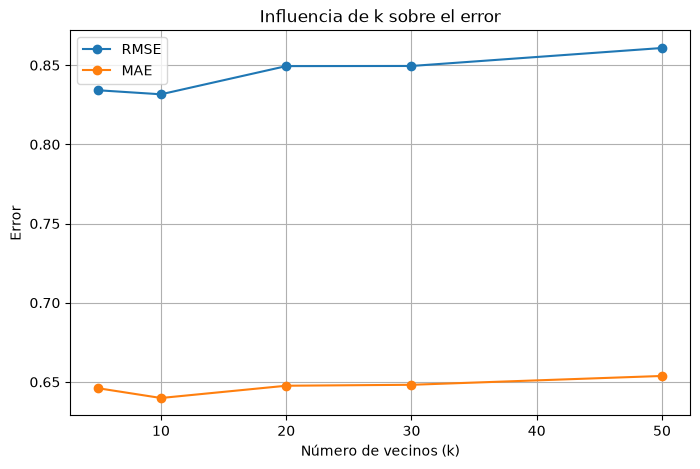

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(metricas["k"], metricas["RMSE"], marker="o")
plt.plot(metricas["k"], metricas["MAE"], marker="o")

plt.xlabel("Número de vecinos (k)")
plt.ylabel("Error")
plt.title("Influencia de k sobre el error")

plt.legend(["RMSE", "MAE"])

plt.grid(True)

plt.show()

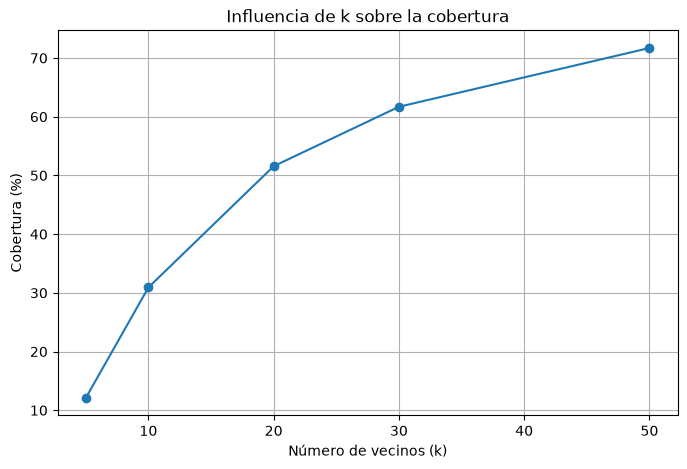

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["k"],
    metricas["Cobertura"],
    marker="o"
)

plt.xlabel("Número de vecinos (k)")
plt.ylabel("Cobertura (%)")
plt.title("Influencia de k sobre la cobertura")

plt.grid(True)

plt.show()